<a href="https://colab.research.google.com/github/Qophy/PBML/blob/main/Model_1_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
raw_data = pd.read_csv('/content/drive/MyDrive/PINN_WQS_dataset/wq_dataset_node_cycles_1.csv')

In [4]:
raw_data.sample(5)

,Temperature,Conductivity,pH,hour_sin,hour_cos,DOW_sin,DOW_cos,Mon_sin,Mon_cos
5979,19.17,301.1,5.77,-1.000000e+00,-1.836970e-16,0.974928,-0.222521,-0.866025,-5.000000e-01
3467,20.56,577.2,6.93,-5.000000e-01,-8.660254e-01,-0.433884,-0.900969,-0.500000,-8.660254e-01
11683,11.75,273.5,6.31,-8.660254e-01,5.000000e-01,0.781831,0.623490,-1.000000,-1.836970e-16
4487,23.47,556.1,8.07,-2.588190e-01,-9.659258e-01,-0.781831,0.623490,-0.500000,-8.660254e-01
13193,12.94,280.5,3.28,1.224647e-16,-1.000000e+00,-0.433884,-0.900969,-0.866025,5.000000e-01


In [5]:
def scale_raw_data(df, scalar=None):
  df = df.copy()
  if not scalar:
    scaler = StandardScaler()
    scaled_dataset = scaler.fit_transform(df)
  else:
    scaled_dataset = scaler.fit_transform(df)

  return scaled_dataset, scaler

In [6]:
# separate inputs and targets
time_var = raw_data[["hour_sin", "hour_cos", "DOW_sin", "DOW_cos", "Mon_sin", "Mon_cos"]].values

env_vars =  raw_data[["Temperature"]].values

targets =  raw_data[["Conductivity", "pH"]].values

In [7]:
time_var_scaled, time_var_scaler = scale_raw_data(time_var)
env_vars_scaled, env_vars_scaler = scale_raw_data(env_vars)
targets_scaled, targets_scaler = scale_raw_data(targets)

In [ ]:
time_var[1][5]

np.float64(-0.8660254037844387)

In [ ]:
time_var_scaled[1][5]


np.float64(-1.127732451050865)

In [8]:
(
    t_train, t_test,
    env_train, env_test,
    y_train, y_test
) = train_test_split(time_var_scaled, env_vars_scaled, targets_scaled, test_size=0.2, random_state=42)

In [ ]:
batch_size = 16

train_dataset = tf.data.Dataset.from_tensor_slices(
    ((t_train, env_train), y_train)
).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices(
    ((t_test, env_test), y_test)
).batch(batch_size)

In [10]:
batch_size = 16

train_dataset = (
    tf.data.Dataset.from_tensor_slices(((t_train, env_train), y_train))
    .shuffle(buffer_size=len(t_train))  # ✅ shuffle training only
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices(((t_test, env_test), y_test))
    .batch(batch_size)  # ❌ no shuffle here
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
for x, y in train_dataset.take(1):
  print(len(x[1]))
  # print(len(y[0]))
  break

16


In [11]:
class SelfAttentionBlock(tf.keras.layers.Layer):

    def __init__(self, d_model):
        super().__init__()

        self.query = tf.keras.layers.Dense(d_model, activation="tanh")
        self.key   = tf.keras.layers.Dense(d_model, activation="tanh")
        self.value = tf.keras.layers.Dense(d_model, activation="tanh")

        self.softmax = tf.keras.layers.Softmax(axis=-1)

    def call(self, x):

        x = tf.expand_dims(x, axis=1)

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        score = tf.matmul(Q, K, transpose_b=True)
        score = score / tf.math.sqrt(tf.cast(tf.shape(K)[-1], tf.float32))

        weights = self.softmax(score)

        h = tf.matmul(weights, V)

        return tf.squeeze(h, axis=1)

In [12]:
def build_nn_branch():

    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(16, activation="tanh"),
        tf.keras.layers.Dense(1)
    ])

In [13]:
def build_interaction_module():

    return tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation="tanh"),
        tf.keras.layers.Dense(32, activation="tanh"),
        tf.keras.layers.Dense(16, activation="tanh")
    ])

In [14]:
class ParallelAttentionInteractionModel(tf.keras.Model):

    def __init__(self, n_targets=2, d_model=32):

        super().__init__()

        self.n_targets = n_targets

        # Parallel attention modules
        self.attention_blocks = [
            SelfAttentionBlock(d_model)
            for _ in range(n_targets)
        ]

        # Parallel NN branches
        self.nn_branches = [
            build_nn_branch()
            for _ in range(n_targets)
        ]

        # Interaction module
        self.interaction = build_interaction_module()

        # Final output heads
        self.output_heads = [
            tf.keras.layers.Dense(1)
            for _ in range(n_targets)
        ]


    def call(self, inputs):

        time_var, env_vars = inputs

        # Input integration
        x = tf.concat([time_var, env_vars], axis=-1)

        # Parallel SA + NN branches
        phi_list = []

        for sa, nn in zip(self.attention_blocks, self.nn_branches):

            h = sa(x)
            phi = nn(h)

            phi_list.append(phi)

        # Level-1 predictions
        phi_L1 = tf.concat(phi_list, axis=-1)

        # Interaction module
        h_interact = self.interaction(phi_L1)

        # Level-2 predictions
        outputs = []

        for head in self.output_heads:

            outputs.append(head(h_interact))

        phi_L2 = tf.concat(outputs, axis=-1)

        return phi_L2

In [15]:
n_targets=2
model = ParallelAttentionInteractionModel(n_targets=n_targets)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=50
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


922/922 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.3760 - mae: 0.4368 - val_loss: 0.3271 - val_mae: 0.4043
Epoch 2/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2924 - mae: 0.3784 - val_loss: 0.2748 - val_mae: 0.3661
Epoch 3/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2618 - mae: 0.3533 - val_loss: 0.2763 - val_mae: 0.3530
Epoch 4/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2390 - mae: 0.3314 - val_loss: 0.2319 - val_mae: 0.3224
Epoch 5/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2167 - mae: 0.3130 - val_loss: 0.2130 - val_mae: 0.3129
Epoch 6/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2021 - mae: 0.2998 - val_loss: 0.2014 - val_mae: 0.2945
Epoch 7/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1916 - mae: 0.2903 - val_loss: 0.1976 - val_mae: 0.2898
Epoch 8/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1843 - mae: 0.2833 - val_loss: 0.1865 - val_mae: 0.2818
Epoch 9/50
922/922 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1771

In [ ]:
n_targets=2
model = ParallelAttentionInteractionModel(n_targets=n_targets)

# Define the learning rate schedule
initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True)

# Create an optimizer with the learning rate schedule
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=200
)

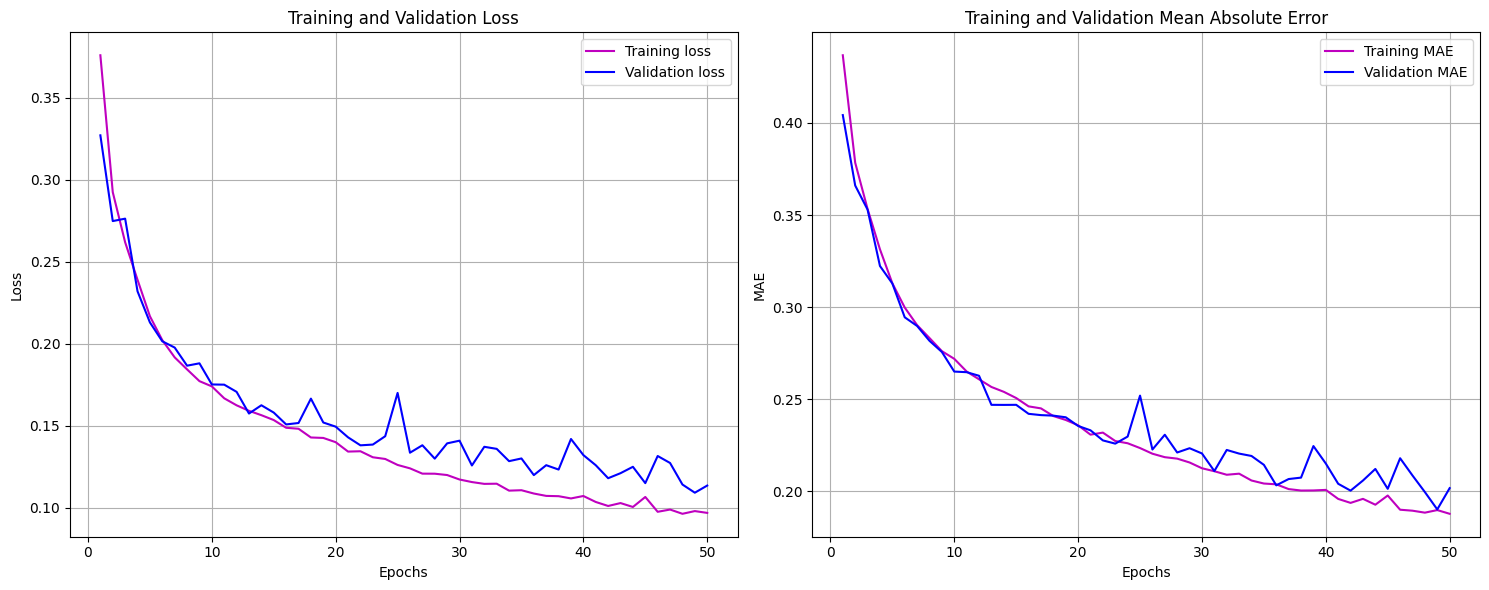

In [16]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract metrics from the history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    epochs = range(1, len(loss) + 1)

    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Plot training and validation loss
    axes[0].plot(epochs, loss, 'm', label='Training loss')
    axes[0].plot(epochs, val_loss, 'b', label='Validation loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Plot training and validation MAE
    axes[1].plot(epochs, mae, 'm', label='Training MAE')
    axes[1].plot(epochs, val_mae, 'b', label='Validation MAE')
    axes[1].set_title('Training and Validation Mean Absolute Error')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.show()

# Call the function to plot the history
plot_training_history(history)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Scale the test set inputs using the scalers fitted on the full dataset
t_test_scaled = time_var_scaler.transform(t_test)
env_test_scaled = env_vars_scaler.transform(env_test)

# Make predictions on the scaled test inputs
predictions_scaled = model.predict((t_test_scaled, env_test_scaled))

# Inverse transform to get predictions and actuals back to original physical units
predictions = targets_scaler.inverse_transform(predictions_scaled)
Y_test_actual = targets_scaler.inverse_transform(y_test)

# Calculate final baseline metrics
rmse = np.sqrt(mean_squared_error(Y_test_actual, predictions))
r2 = r2_score(Y_test_actual, predictions)
mae = mean_absolute_error(Y_test_actual, predictions)

print(f"\n--- Evaluation Metrics ---")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R-squared: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")

 28/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(



--- Evaluation Metrics ---
Test RMSE: 100.0342
Test R-squared: -0.8575
Test MAE: 51.2297


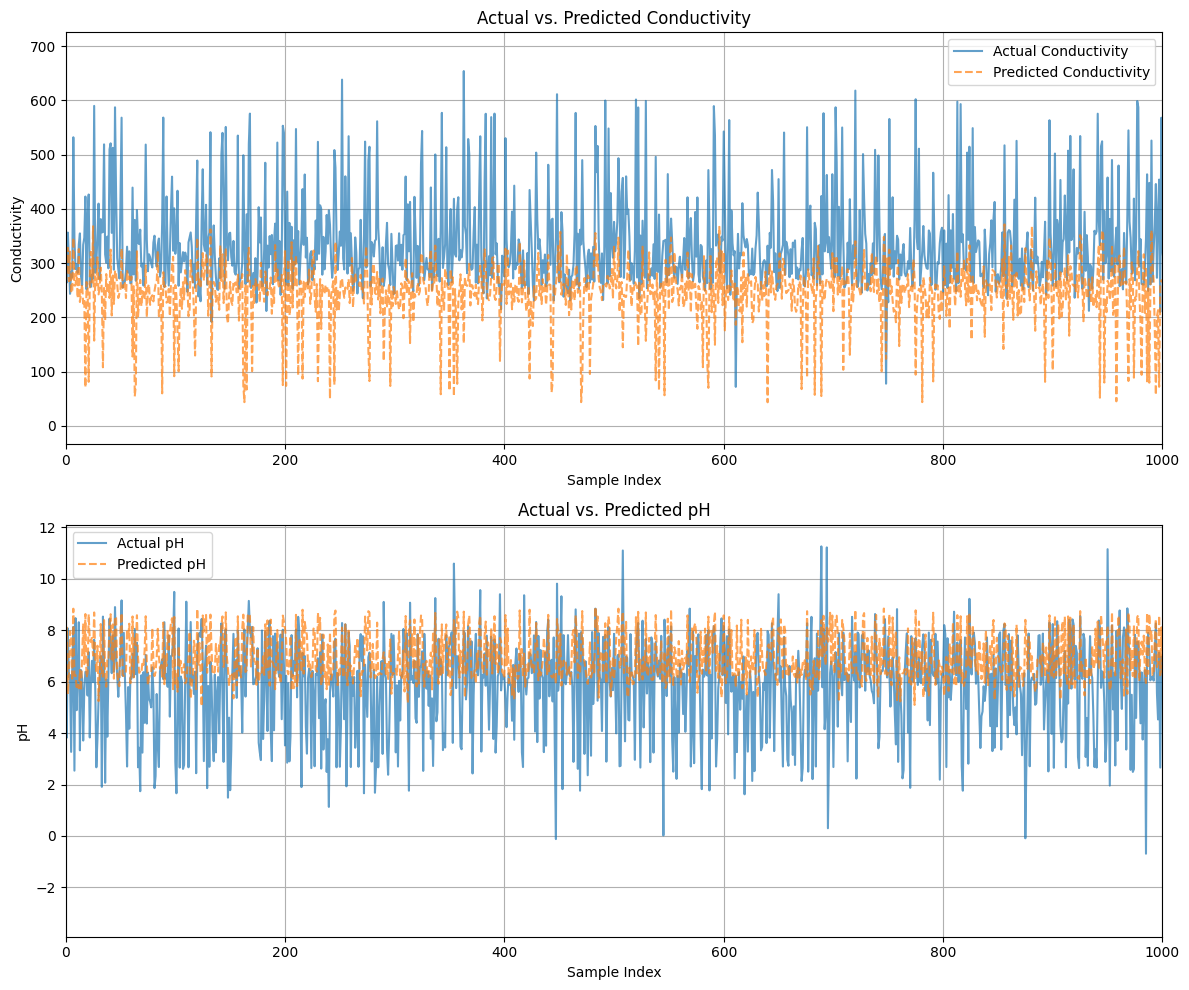

In [18]:
import matplotlib.pyplot as plt

# Create a 2x1 figure for the plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot for the first target (Conductivity)
axes[0].plot(Y_test_actual[:, 0], label='Actual Conductivity', alpha=0.7)
axes[0].plot(predictions[:, 0], label='Predicted Conductivity', alpha=0.7, linestyle='--')
axes[0].set_title('Actual vs. Predicted Conductivity')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Conductivity')
axes[0].legend()
axes[0].grid(True)
axes[0].set_xlim(0, 1000) # Zoom in on x-axis

# Plot for the second target (pH)
axes[1].plot(Y_test_actual[:, 1], label='Actual pH', alpha=0.7)
axes[1].plot(predictions[:, 1], label='Predicted pH', alpha=0.7, linestyle='--')
axes[1].set_title('Actual vs. Predicted pH')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('pH')
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlim(0, 1000) # Zoom in on x-axis

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()